
Evaluating Noise Level: 1.0
 Seed 0 complete...
 Seed 20 complete...
 Seed 40 complete...
 Seed 60 complete...
 Seed 80 complete...

Evaluating Noise Level: 2.0
 Seed 0 complete...
 Seed 20 complete...
 Seed 40 complete...
 Seed 60 complete...
 Seed 80 complete...

Evaluating Noise Level: 3.0
 Seed 0 complete...
 Seed 20 complete...
 Seed 40 complete...
 Seed 60 complete...
 Seed 80 complete...


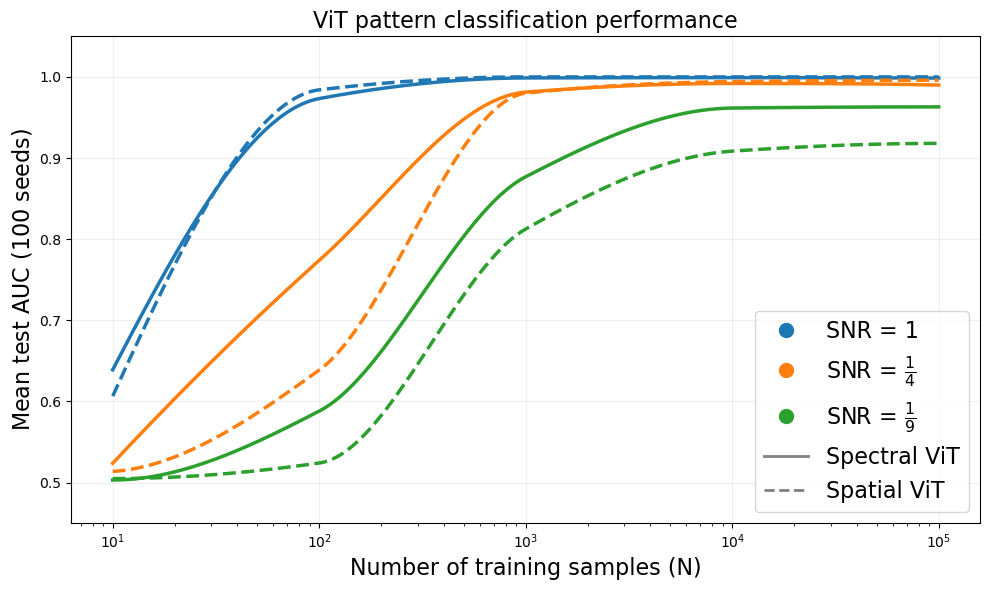

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.interpolate import make_interp_spline
from util import seed_everything
import matplotlib.lines as mlines
from scipy.interpolate import PchipInterpolator
import matplotlib.lines as mlines

# Configuration
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
N_COMPONENTS = 16 
N_SEEDS = 100
SIZES = [10, 100, 1000, 10000, 100000]
NOISE_LEVELS = [1.0, 2.0, 3.0]
COLORS = {1.0: 'tab:blue', 2.5: 'tab:orange', 5.0: 'tab:green'}

# Checkerboard Generator
def generate_checkerboard_data(n_samples, img_size=28, noise_level=1.0):
    images, labels = [], []
    for _ in range(n_samples):
        label = np.random.randint(0, 2)
        noise = np.random.normal(0, noise_level, img_size * img_size)
        if label == 1:
            b_size = np.random.randint(3, 6)
            pad = 8
            large_size = img_size + pad
            base = np.indices((large_size // b_size + 1, large_size // b_size + 1)).sum(axis=0) % 2
            checker = base.repeat(b_size, axis=0).repeat(b_size, axis=1)
            y_off, x_off = np.random.randint(0, pad), np.random.randint(0, pad)
            checker = checker[y_off:y_off+img_size, x_off:x_off+img_size]
            checker = (checker.astype(float) * 2) - 1
            mask = np.random.binomial(1, 0.8, size=(img_size, img_size))
            img = noise + (1.0 * (checker * mask).flatten()) 
        else:
            img = noise
        images.append(img); labels.append(label)
    return np.array(images), np.array(labels)

# Models (Spectral & Spatial ViT)
class SpectralViT(nn.Module):
    def __init__(self, n_inputs, embed_dim=16):
        super().__init__()
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.register_buffer('rank_weights', 1.0 / ranks)
        self.input_proj = nn.Linear(1, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, n_inputs, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=2, dim_feedforward=32, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        if x.dim() == 1: x = x.unsqueeze(0)
        x = x * self.rank_weights
        x = self.input_proj(x.unsqueeze(-1)) + self.pos_embed[:, :x.size(1), :] 
        return torch.sigmoid(self.fc(self.transformer(x.transpose(0, 1)).mean(dim=0)).squeeze())
    
class SpatialViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, embed_dim=16):
        super().__init__()
        self.patch_size, self.n_patches = patch_size, (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=2, dim_feedforward=32, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        b = x.shape[0]
        x = x.view(b, 1, 28, 28)
        p = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        p = p.contiguous().view(b, self.n_patches, -1)
        x = self.transformer((self.proj(p) + self.pos_embed).transpose(0, 1)).mean(dim=0)
        return torch.sigmoid(self.fc(x).squeeze())

# Execution logic
results = {nl: {'spec': [], 'spat': []} for nl in NOISE_LEVELS}

for nl in NOISE_LEVELS:
    print(f"\nEvaluating Noise Level: {nl}")
    spec_res = np.zeros((N_SEEDS, len(SIZES)))
    spat_res = np.zeros((N_SEEDS, len(SIZES)))
    
    for seed_idx in range(N_SEEDS):
        seed_everything(seed_idx)
        for size_idx, n_samples in enumerate(SIZES):
            X_tr_raw, y_tr = generate_checkerboard_data(n_samples, noise_level=nl)
            X_te_raw, y_te = generate_checkerboard_data(500, noise_level=nl)
            
            scaler = StandardScaler().fit(X_tr_raw)
            X_tr_s, X_te_s = scaler.transform(X_tr_raw), scaler.transform(X_te_raw)
            pca = PCA(n_components=min(n_samples-1, N_COMPONENTS), whiten=True).fit(X_tr_s)
            
            y_tensor = torch.tensor(y_tr, dtype=torch.float32).to(device)
            m_spec, m_spat = SpectralViT(pca.n_components_).to(device), SpatialViT().to(device)
            opt_spec, opt_spat = optim.Adam(m_spec.parameters(), lr=1e-3), optim.Adam(m_spat.parameters(), lr=1e-3)
            
            xt_spec = torch.tensor(pca.transform(X_tr_s), dtype=torch.float32).to(device)
            xt_spat = torch.tensor(X_tr_s, dtype=torch.float32).to(device)
            
            for _ in range(100):
                F.binary_cross_entropy(m_spec(xt_spec), y_tensor).backward(); opt_spec.step(); opt_spec.zero_grad()
                F.binary_cross_entropy(m_spat(xt_spat), y_tensor).backward(); opt_spat.step(); opt_spat.zero_grad()
            
            with torch.no_grad():
                spec_res[seed_idx, size_idx] = roc_auc_score(y_te, m_spec(torch.tensor(pca.transform(X_te_s), dtype=torch.float32).to(device)).cpu().numpy())
                spat_res[seed_idx, size_idx] = roc_auc_score(y_te, m_spat(torch.tensor(X_te_s, dtype=torch.float32).to(device)).cpu().numpy())
        if seed_idx % 20 == 0: print(f" Seed {seed_idx} complete...")
        
    results[nl]['spec'] = spec_res
    results[nl]['spat'] = spat_res

# Define the colors based on your noise levels
# nl=1.0 -> SNR=1/1, nl=2.0 -> SNR=1/4, nl=3.0 -> SNR=1/9
SNR_COLORS = {1.0: 'tab:blue', 2.0: 'tab:orange', 3.0: 'tab:green'}

def smooth_curve(x, y):
    x, y = np.array(x), np.array(y)
    if len(x) <= 2: return x, y
    x_log = np.log10(x)
    x_new_log = np.linspace(x_log.min(), x_log.max(), 1000)
    interp = PchipInterpolator(x_log, y)
    y_smooth = interp(x_new_log)
    return 10**x_new_log, np.clip(y_smooth, 0, 1.0)

plt.figure(figsize=(10, 6))

# Plotting logic
for nl in NOISE_LEVELS:
    c = SNR_COLORS.get(nl, 'black')
    
    # Spectral (Solid)
    mean_spec = np.mean(results[nl]['spec'], axis=0)
    x_s, y_s = smooth_curve(SIZES, mean_spec)
    plt.plot(x_s, y_s, color=c, lw=2.5, linestyle='-')
    
    # Spatial (Dashed)
    mean_spat = np.mean(results[nl]['spat'], axis=0)
    x_p, y_p = smooth_curve(SIZES, mean_spat)
    plt.plot(x_p, y_p, color=c, lw=2.5, linestyle='--')

# --- Consolidated Legend with LaTeX Fractions and Solid Circles ---

# 1. Create color proxies for SNR as solid circles
snr_proxies = []
for nl, color in SNR_COLORS.items():
    denom = int(nl**2)
    label_str = f'SNR = $\\frac{{1}}{{{denom}}}$' if denom > 1 else 'SNR = 1'
    # Use linestyle='None' and marker='o' for solid circles
    snr_proxies.append(mlines.Line2D([], [], color=color, label=label_str, 
                                     marker='o', linestyle='None', markersize=10))

# 2. Create style proxies for Model Type
model_proxies = [
    mlines.Line2D([], [], color='gray', linestyle='-', lw=2, label='Spectral ViT'),
    mlines.Line2D([], [], color='gray', linestyle='--', lw=2, label='Spatial ViT')
]

# Combine and apply
plt.legend(handles=snr_proxies + model_proxies, loc='lower right', frameon=True, fontsize=16)

# Formatting
plt.xscale('log')
plt.xlabel('Number of training samples (N)', fontsize=16)
plt.ylabel('Mean test AUC ($100$ seeds)', fontsize=16)
plt.title('ViT pattern classification performance', fontsize=16)
plt.grid(True, alpha=0.2)
plt.ylim(0.45, 1.05)
plt.tight_layout()
plt.show()

In [2]:
def find_crossover_values(sizes, results_dict):
    # This matches the smoothing used in your plotting code
    def get_smooth_data(x, y):
        x_log = np.log10(x)
        x_new_log = np.linspace(x_log.min(), x_log.max(), 1000)
        interp = PchipInterpolator(x_log, y)
        return 10**x_new_log, interp(x_new_log)

    for nl in [1.0, 2.0, 3.0]:
        if nl not in results_dict: continue
            
        data = results_dict[nl]
        mean_spec = np.mean(data['spec'], axis=0)
        mean_spat = np.mean(data['spat'], axis=0)
        
        # 1. Generate high-resolution smoothed curves (1000 points)
        x_high, y_spec_high = get_smooth_data(sizes, mean_spec)
        _, y_spat_high = get_smooth_data(sizes, mean_spat)
        
        # 2. Calculate the difference on the high-res curve
        diff = y_spec_high - y_spat_high
        
        # 3. Find where the sign flips
        # We look for indices where diff goes from positive to negative or vice-versa
        cross_indices = np.where(np.diff(np.sign(diff)))[0]
        
        snr_label = f"1/{int(nl**2)}" if nl > 1 else "1"
        
        # Filter out "starting line" noise at N=10
        valid_crossings = [i for i in cross_indices if x_high[i] > 12]

        if valid_crossings:
            # We take the first meaningful tie point
            idx = valid_crossings[0]
            tie_n = x_high[idx]
            
            # Determine leader behavior
            leader = "Spectral" if diff[0] > 0 else "Spatial"
            print(f"SNR {snr_label}: {leader} leads until N ≈ {tie_n:.2f} (Tie Point)")
        else:
            winner = "Spectral" if np.mean(diff) > 0 else "Spatial"
            print(f"SNR {snr_label}: No crossover ({winner} leads throughout)")

# Execute
find_crossover_values(SIZES, results)

SNR 1: Spectral leads until N ≈ 31.66 (Tie Point)
SNR 1/4: Spectral leads until N ≈ 1683.55 (Tie Point)
SNR 1/9: Spatial leads until N ≈ 13.56 (Tie Point)


Spatial lead at $SNR=\frac{1}{9}$ is at $AUC \approx 0.5$, not meaningful.

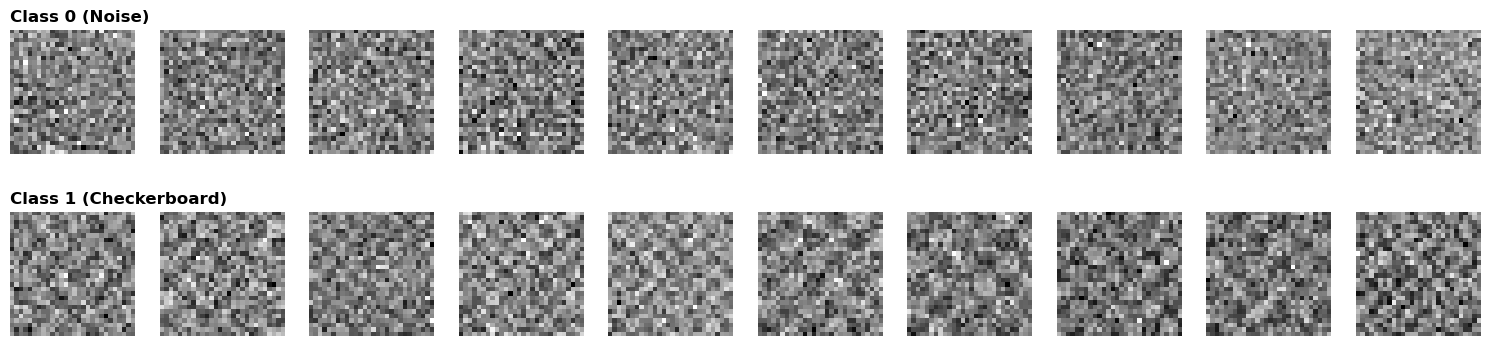

In [3]:
def visualize_samples(n_samples_per_class=10, img_size=28):
    # Generate a pool of samples
    # We generate more than needed to ensure we can pick exactly 10 of each
    X_raw, y_raw = generate_checkerboard_data(n_samples=100)
    
    # Filter classes
    class_0_idx = np.where(y_raw == 0)[0][:n_samples_per_class]
    class_1_idx = np.where(y_raw == 1)[0][:n_samples_per_class]
    
    fig, axes = plt.subplots(2, n_samples_per_class, figsize=(15, 4))
    
    for i in range(n_samples_per_class):
        # Row 0: Class 0 (Pure Noise)
        img0 = X_raw[class_0_idx[i]].reshape(img_size, img_size)
        axes[0, i].imshow(img0, cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Class 0 (Noise)", loc='left', fontweight='bold')
            
        # Row 1: Class 1 (Checkerboard + Noise)
        img1 = X_raw[class_1_idx[i]].reshape(img_size, img_size)
        axes[1, i].imshow(img1, cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("Class 1 (Checkerboard)", loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Call the function
visualize_samples()

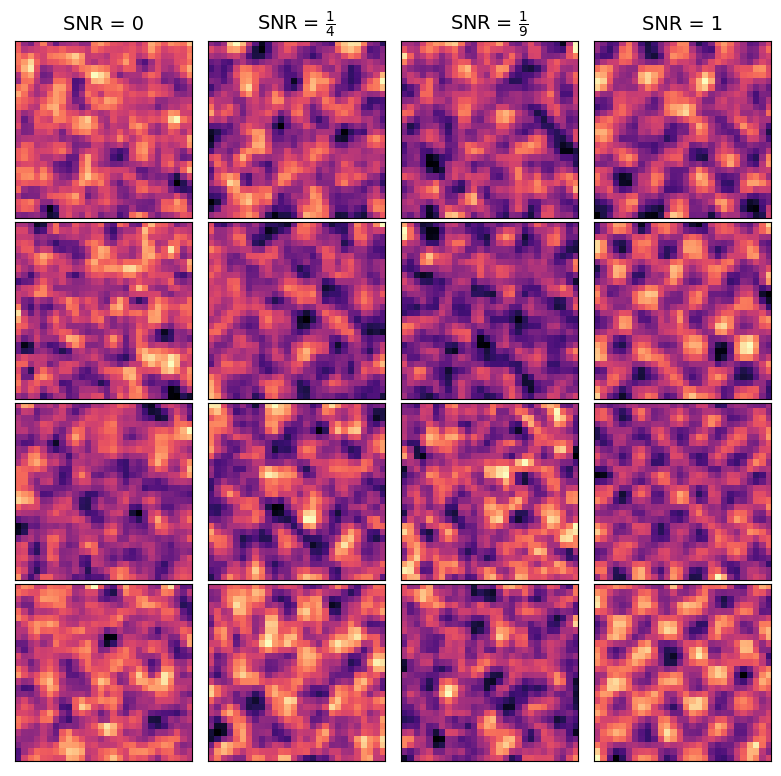

In [4]:
from scipy.ndimage import gaussian_filter

def visualize_snr_grid_denoised():
    snr_configs = [
        {'label': 'SNR = 0', 'sigma': 1.0, 'pure_noise': True},
        {'label': r'SNR = $\frac{1}{4}$', 'sigma': 2.0, 'pure_noise': False},
        {'label': r'SNR = $\frac{1}{9}$', 'sigma': 3.0, 'pure_noise': False},
        {'label': 'SNR = 1', 'sigma': 1.0, 'pure_noise': False}
    ]
    
    n_instances = 4
    img_size = 28
    
    fig, axes = plt.subplots(n_instances, len(snr_configs), 
                             figsize=(8, 8), 
                             gridspec_kw={'wspace': 0.02, 'hspace': 0.02})
    
    for col_idx, config in enumerate(snr_configs):
        # Generate fresh data
        X, y = generate_checkerboard_data(n_samples=100, noise_level=config['sigma'])
        imgs = X[y == (0 if config['pure_noise'] else 1)][:n_instances]
            
        for row_idx in range(n_instances):
            ax = axes[row_idx, col_idx]
            img = imgs[row_idx].reshape(img_size, img_size)
            
            # 1. Apply a Gaussian filter to suppress pixel-level noise
            # sigma=0.8 to 1.2 is the 'sweet spot' for 28x28 images
            img_smooth = gaussian_filter(img, sigma=0.8)
            
            # 2. Local contrast stretch (Normalize the smoothed image)
            img_smooth = (img_smooth - img_smooth.min()) / (img_smooth.max() - img_smooth.min())
            
            # 3. Use a high-contrast grayscale
            ax.imshow(img_smooth, cmap='magma', aspect='equal')
            
            ax.set_xticks([]); ax.set_yticks([])
            
            if row_idx == 0:
                ax.set_title(config['label'], fontsize=14, pad=8)

    plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)
    plt.show()

visualize_snr_grid_denoised()